In [1]:
!pip install open_clip_torch peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [2]:
import os
import gc
import random
import warnings
import ctypes
from tqdm import tqdm

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.manifold import TSNE

import math
import numpy as np 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy
from scipy.special import softmax
from scipy.spatial.distance import jensenshannon

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import open_clip
from transformers import CLIPVisionModel, AutoTokenizer, AutoModel, CLIPTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model

In [3]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    
    warnings.filterwarnings("ignore")
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)

    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % (2 ** 32)
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    print(f"Random seed: {seed}")
    return seed_worker

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except:
        pass

In [4]:
class NPZDataset(Dataset):
    def __init__(self, npz_path, split="train", transform=None):
        data = np.load(npz_path)
        self.split = split
        if split == "train":
            self.train_img = data["train_images"]
            self.val_img = data["val_images"]
            
            self.train_lbl = data["train_labels"].squeeze()
            self.val_lbl = data["val_labels"].squeeze()
            self.lbl = np.concatenate((self.train_lbl, self.val_lbl), axis=0)
            
            self.len_train = len(self.train_img)
            self.total_len = self.len_train + len(self.val_img)
        elif split == "test":
            self.img = data["test_images"]
            self.lbl = data["test_labels"].squeeze()
            self.total_len = len(self.img)
        else:
            raise ValueError("Split must be 'train' or 'test'")
            
        self.transform = transform
        self.classes = [
            "adipose", "background", "debris", "lymphocytes", "mucus", 
            "smooth_muscle", "normal_colon_mucosa", "cancer_associated_stroma", 
            "colorectal_adenocarcinoma"
        ]

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        if self.split == "train":
            if idx < self.len_train:
                img = self.train_img[idx]
                label = self.lbl[idx]
            else:
                val_idx = idx - self.len_train
                img = self.val_img[val_idx]
                label = self.lbl[idx]
        else:
            img = self.img[idx]
            label = self.lbl[idx]
            
        img = Image.fromarray(img)
        if self.transform: 
            img = self.transform(img)
        return img, label

In [5]:
class ActiveLearningDataset(Dataset):
    def __init__(self, subset, labels):
        self.subset = subset
        self.labels = labels
        
    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        img, _ = self.subset[idx] 
        return img, self.labels[idx]

In [6]:
def get_data_loaders(data_path, seed):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    if data_path.endswith(".npz"):
        train_dataset = NPZDataset(npz_path=data_path, split="train", transform=transform)
        test_dataset = NPZDataset(npz_path=data_path, split="test", transform=transform)
        class_names = train_dataset.classes
    else:
        full_dataset = ImageFolder(root=data_path, transform=transform)
        class_names = full_dataset.classes
        
        total_size = len(full_dataset)
        train_size = int(0.8 * total_size)
        test_size = total_size - train_size
        generator = torch.Generator().manual_seed(seed)
        train_dataset, test_dataset = random_split(
            full_dataset, 
            [train_size, test_size], 
            generator=generator
        )

    print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

    train_loader = DataLoader(
        train_dataset, 
        batch_size=256, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=256, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    return train_loader, test_loader, class_names

In [7]:
class MedicalFusionModel(nn.Module):
    def __init__(self, 
                 num_classes, 
                 r, 
                 lora_alpha, 
                 lora_dropout=0.1): 
        super(MedicalFusionModel, self).__init__()
        
        backbone_plip = CLIPVisionModel.from_pretrained("vinid/plip")
        biomed_full, _, _ = open_clip.create_model_and_transforms("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
        backbone_biomed = biomed_full.visual 

        config_plip = LoraConfig(
            r=r, 
            lora_alpha=lora_alpha, 
            target_modules=["q_proj", "v_proj"], 
            lora_dropout=lora_dropout, 
            bias="none"
        )
        config_biomed = LoraConfig(
            r=r, 
            lora_alpha=lora_alpha, 
            target_modules=["qkv", "in_proj", "out_proj"], 
            lora_dropout=lora_dropout, 
            bias="none"
        )

        self.backbone_plip = get_peft_model(backbone_plip, config_plip)
        self.backbone_biomed = get_peft_model(backbone_biomed, config_biomed)

        dummy_x = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            feat1 = self.backbone_plip(pixel_values=dummy_x).pooler_output
            feat2 = self.backbone_biomed(dummy_x)
            if isinstance(feat2, tuple): feat2 = feat2[0]
                
        fused_dim = feat1.shape[1] + feat2.shape[1]

        self.projection_head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.classification_head = nn.Linear(256, num_classes)

    def forward(self, x):
        plip_outputs = self.backbone_plip(pixel_values=x)
        f_plip = plip_outputs.pooler_output
        f_biomed = self.backbone_biomed(x)
        if isinstance(f_biomed, tuple): 
            f_biomed = f_biomed[0]
            
        f_fused = torch.cat((f_plip, f_biomed), dim=1) 
        f_proj = self.projection_head(f_fused)
        logits = self.classification_head(f_proj)
        
        return f_proj, logits, f_fused

In [8]:
@torch.inference_mode() 
def extract_embeddings(dataloader, model, device):
    model = model.to(device)
    model.eval()

    all_embeddings_256, all_probs, all_embeddings_fused = [], [], []

    for images, _ in tqdm(dataloader, desc="Extracting Features", leave=False):
        images = images.to(device, non_blocking=True)
        with autocast():
            f_proj, logits, f_fused = model(images)
            probs = F.softmax(logits, dim=1)
        
        all_embeddings_256.append(f_proj.cpu().numpy().astype(np.float32))
        all_probs.append(probs.cpu().numpy().astype(np.float32))
        all_embeddings_fused.append(f_fused.cpu().numpy().astype(np.float32))

    embeddings_256 = np.vstack(all_embeddings_256)
    probabilities = np.vstack(all_probs)
    embeddings_fused = np.vstack(all_embeddings_fused)
    
    del all_embeddings_256, all_probs, all_embeddings_fused
    clear_memory()
    
    return embeddings_256, probabilities, embeddings_fused

In [9]:
def extract_text_embeddings(class_descriptions, prompt_templates, class_names, device):
    detailed_descriptions = [class_descriptions.get(cls, cls) for cls in class_names]
    all_prompts = []
    for desc in detailed_descriptions:
        for template in prompt_templates:
            all_prompts.append(template.format(desc))
    
    tokenizer_bio = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext")
    encoder_bio = AutoModel.from_pretrained("microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext").to(device).eval()
    
    tokenizer_plip = CLIPTokenizer.from_pretrained("vinid/plip")
    encoder_plip = CLIPTextModel.from_pretrained("vinid/plip").to(device).eval()
    
    tokens_bio = tokenizer_bio(
        all_prompts, 
        padding=True, 
        truncation=True, 
        return_tensors="pt"
    ).to(device)
    with torch.no_grad(): 
        emb_bio = encoder_bio(**tokens_bio).pooler_output.cpu().numpy()
    
    tokens_plip = tokenizer_plip(
        all_prompts, 
        padding=True, 
        truncation=True, 
        return_tensors="pt"
    ).to(device)
    with torch.no_grad(): 
        emb_plip = encoder_plip(**tokens_plip).pooler_output.cpu().numpy()
    
    fused_raw_embeddings = np.concatenate((emb_plip, emb_bio), axis=1)
    
    text_embeddings_fused = fused_raw_embeddings.reshape(len(class_names), len(prompt_templates), -1).mean(axis=1)
    text_embeddings_fused = text_embeddings_fused / np.linalg.norm(text_embeddings_fused, axis=1, keepdims=True)
    
    del encoder_bio, encoder_plip, tokens_bio, tokens_plip, emb_bio, emb_plip, fused_raw_embeddings
    clear_memory()

    return text_embeddings_fused

In [10]:
class CenterLoss(nn.Module):
    def __init__(self, num_classes=14, feat_dim=256, device=torch.device('cuda')):
        super(CenterLoss, self).__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.device = device        
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim).to(device))

    def forward(self, features, labels):
        batch_size = features.size(0)        
        features = F.normalize(features, p=2, dim=1)
        centers_batch = self.centers.index_select(0, labels)
        loss = (features - centers_batch).pow(2).sum() / 2.0 / batch_size
        return loss

In [11]:
def train_center_loss(model, labeled_loader, epochs, learn_rate, device):
    model = model.to(device)
    model.train() 
    num_classes = model.classification_head.out_features
    feat_dim = model.classification_head.in_features
    
    if hasattr(labeled_loader.dataset, "labels"):
        all_labels = labeled_loader.dataset.labels
        valid_labels = all_labels[all_labels >= 0]
        class_counts = np.bincount(valid_labels, minlength=num_classes)
    else:
        class_counts = np.zeros(num_classes)
        for _, labels in labeled_loader:
            counts = np.bincount(labels.cpu().numpy(), minlength=num_classes)
            class_counts += counts
    total_samples = np.sum(class_counts)
    class_weights = np.ones(num_classes, dtype=np.float32)    
    for c in range(num_classes):
        if class_counts[c] > 0:
            class_weights[c] = total_samples / (num_classes * class_counts[c])
        else:
            class_weights[c] = 0.0    
            
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer_model = optim.AdamW(trainable_params, lr=learn_rate, weight_decay=1e-4)    
    criterion_ce = nn.CrossEntropyLoss(weight=weight_tensor)
    criterion_center = CenterLoss(num_classes=num_classes, feat_dim=feat_dim, device=device)
    optimizer_center = optim.SGD(criterion_center.parameters(), lr=0.5)   
    alpha = 0.05  
    scaler = GradScaler()
    
    for epoch in range(epochs):
        running_loss = 0.0
        batches = 0
        for images, labels in labeled_loader:
            images, labels = images.to(device), labels.long().to(device)
            optimizer_model.zero_grad()
            optimizer_center.zero_grad()
            with autocast():
                f_proj, logits, _ = model(images)
                loss_ce = criterion_ce(logits, labels)
                loss_cent = criterion_center(f_proj, labels)
                loss_total = loss_ce + alpha * loss_cent                
            scaler.scale(loss_total).backward()
            scaler.step(optimizer_model)
            scaler.step(optimizer_center)
            scaler.update()
            running_loss += loss_total.item()
            batches += 1
        avg_loss = running_loss / batches if batches > 0 else 0
        print(f"Epoch [{epoch + 1:02d}/{epochs}] | Loss: {avg_loss:.4f}")
        
    return model

In [12]:
def evaluate_model(model, test_loader, true_labels, class_names, device):
    _, probs, _ = extract_embeddings(test_loader, model, device=device)
    preds = np.argmax(probs, axis=1)
    
    acc = accuracy_score(true_labels, preds)
    pre = precision_score(true_labels, preds, average="macro", zero_division=0)
    rec = recall_score(true_labels, preds, average="macro", zero_division=0)
    f1 = f1_score(true_labels, preds, average="macro", zero_division=0)
    
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {pre * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"Macro F1 : {f1 * 100:.2f}%")
    
    return acc, pre, rec, f1

In [13]:
def visualize_tsne(embeddings_256, true_labels, class_names, iteration, color_map, seed, max_samples=25000):
    if len(embeddings_256) > max_samples:
        np.random.seed(seed)
        indices = np.random.choice(len(embeddings_256), max_samples, replace=False)
        X_feat = embeddings_256[indices]
        y_lbl = true_labels[indices]
    else:
        X_feat = embeddings_256
        y_lbl = true_labels
        
    tsne = TSNE(n_components=2, random_state=seed, perplexity=30, n_jobs=-1)
    X_2d = tsne.fit_transform(X_feat)
    
    plt.figure(figsize=(12, 9))
    label_names = [class_names[lbl] for lbl in y_lbl]
    hue_order = sorted(class_names) 
    
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=label_names, hue_order=hue_order, palette=color_map,   
        legend="full", alpha=0.7, s=20 
    )
    
    plt.title(f"t-SNE Pre-Train" if iteration == 0 else "t-SNE Post-Train", fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.tight_layout()
    
    os.makedirs("tsne_plots", exist_ok=True)
    save_path = f"tsne_plots/tsne_train_iter_{iteration}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    
    del X_feat, y_lbl, X_2d, label_names
    clear_memory()

In [14]:
def plot_tsne_evolution_grid(image_dir="tsne_plots", total_images=2):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(24, 14))
    axes = axes.flatten() 
    
    for i in range(total_images):
        img_path = os.path.join(image_dir, f"tsne_train_iter_{i}.png")
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
        else:
            axes[i].text(0.5, 0.5, f"[Không tìm thấy ảnh Iter {i}]", 
                         ha="center", va="center", fontsize=14, color="red")
        axes[i].axis("off")
        
    plt.suptitle("Embedding Space (Pre-Train vs Post-Train)", 
                 fontsize=26, fontweight="bold", y=1.02)
    plt.tight_layout()
    
    combined_save_path = os.path.join(image_dir, "tsne_grid.png")
    plt.savefig(combined_save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
def active_learning_pipeline(model, 
                             full_dataset, 
                             oracle_labels, 
                             test_loader, 
                             test_labels, 
                             class_names,
                             text_embeddings_fused, 
                             color_map, 
                             total_budget, 
                             num_epochs, 
                             learn_rate,
                             lambda_tradeoff, 
                             r, 
                             device, 
                             seed_worker_fn, 
                             g_seed, 
                             seed):
    
    num_samples = len(full_dataset)
    
    full_loader = DataLoader(
        full_dataset, 
        batch_size=256, 
        shuffle=False, 
        num_workers=4,
        worker_init_fn=seed_worker_fn, 
        generator=g_seed
    )
    
    print("Trích xuất Embeddings...")
    embeddings_256, probs, embeddings_fused = extract_embeddings(full_loader, model, device=device)
    
    visualize_tsne(
        embeddings_256, 
        oracle_labels, 
        class_names, 
        iteration=0, 
        color_map=color_map, 
        seed=seed
    )
    del embeddings_256
    clear_memory()

    sim_matrix_0 = cosine_similarity(embeddings_fused, text_embeddings_fused)
    probs_for_margin = softmax(sim_matrix_0 / 0.05, axis=1) 
        
    sorted_probs = np.sort(probs_for_margin, axis=1)
    margins = sorted_probs[:, -1] - sorted_probs[:, -2]
    
    predicted_classes = np.argmax(probs_for_margin, axis=1)
    one_hot_preds = np.zeros_like(probs_for_margin)
    one_hot_preds[np.arange(num_samples), predicted_classes] = 1.0
    
    jsd_scores = jensenshannon(probs_for_margin, one_hot_preds, axis=1) ** 2
    uncertainty_weights = (1.0 - margins) * (1.0 + jsd_scores)
    
    if uncertainty_weights.max() > 0:
        uncertainty_weights = uncertainty_weights / uncertainty_weights.max()

    final_queries_idx = []
    chunk_size = 10000 
    
    unlabeled_tensor = torch.tensor(embeddings_fused, device=device)
    unlabeled_tensor = F.normalize(unlabeled_tensor, p=2, dim=1)
    uncertainty_tensor = torch.tensor(uncertainty_weights, device=device)
    max_sim_to_S = torch.full((num_samples, 1), -float('inf'), device=device)
    
    print(f"\nGreedy Algorithm chọn {total_budget} ảnh...")
    for step in tqdm(range(total_budget), desc="Drafting"):
        global_max_coverage = 0.0
        
        for chunk_start in range(0, num_samples, chunk_size):
            chunk_end = min(chunk_start + chunk_size, num_samples)
            chunk_tensor = unlabeled_tensor[chunk_start:chunk_end]
            
            sim_chunk = torch.matmul(unlabeled_tensor, chunk_tensor.T)
            gain_chunk = torch.clamp(sim_chunk - max_sim_to_S, min=0.0)
            coverage_gain_chunk = torch.sum(gain_chunk, dim=0)
            
            local_max = torch.max(coverage_gain_chunk).item()
            if local_max > global_max_coverage:
                global_max_coverage = local_max
                
            del chunk_tensor, sim_chunk, gain_chunk, coverage_gain_chunk
            clear_memory()
        
        best_candidate_global = -1
        best_objective_score = -float("inf")
        best_sim_column = None
        
        for chunk_start in range(0, num_samples, chunk_size):
            chunk_end = min(chunk_start + chunk_size, num_samples)
            chunk_tensor = unlabeled_tensor[chunk_start:chunk_end]
            chunk_uncert = uncertainty_tensor[chunk_start:chunk_end]
            
            sim_chunk = torch.matmul(unlabeled_tensor, chunk_tensor.T)
            gain_chunk = torch.clamp(sim_chunk - max_sim_to_S, min=0.0)
            coverage_gain_chunk = torch.sum(gain_chunk, dim=0)
            
            if global_max_coverage > 0:
                normalized_coverage = coverage_gain_chunk / global_max_coverage
            else:
                normalized_coverage = torch.zeros_like(coverage_gain_chunk)
                
            objective_scores = (1 - lambda_tradeoff) * normalized_coverage + (lambda_tradeoff) * chunk_uncert
            
            for selected_idx in final_queries_idx:
                if chunk_start <= selected_idx < chunk_end:
                    local_idx_in_chunk = selected_idx - chunk_start
                    objective_scores[local_idx_in_chunk] = -float('inf')
                    
            local_best_idx = torch.argmax(objective_scores).item()
            local_best_score = objective_scores[local_best_idx].item()
            
            if local_best_score > best_objective_score or best_sim_column is None:
                best_objective_score = local_best_score
                best_candidate_global = chunk_start + local_best_idx
                best_sim_column = sim_chunk[:, local_best_idx].reshape(-1, 1).clone() 
                
            del chunk_tensor, chunk_uncert, sim_chunk, gain_chunk, coverage_gain_chunk, objective_scores
            clear_memory()
            
        if best_sim_column is not None:
            final_queries_idx.append(best_candidate_global)
            max_sim_to_S = torch.maximum(max_sim_to_S, best_sim_column)
            del best_sim_column
            clear_memory()
        else:
            print("Không tìm được ứng viên hợp lệ!")
            break
            
    del unlabeled_tensor, uncertainty_tensor, max_sim_to_S
    clear_memory()

    queried_labels = oracle_labels[final_queries_idx]
    
    del probs, embeddings_fused
    del sorted_probs, margins
    del predicted_classes, one_hot_preds, jsd_scores, uncertainty_weights
    clear_memory()

    train_subset = Subset(full_dataset, final_queries_idx)
    al_dataset = ActiveLearningDataset(train_subset, queried_labels)
    train_loader = DataLoader(
        al_dataset, 
        batch_size=32, 
        shuffle=True, 
        worker_init_fn=seed_worker_fn, 
        generator=g_seed
    )
    
    print(f"\nFine-tune LoRA Contrastive trên {total_budget} ảnh...")
    num_classes_total = len(class_names)
    del model 
    clear_memory() 
    
    model = MedicalFusionModel(
        num_classes=num_classes_total, 
        r=r, 
        lora_alpha=r * 2
    ).to(device)
    
    model = train_center_loss(
        model, 
        train_loader, 
        epochs=num_epochs, 
        learn_rate=learn_rate, 
        device=device
    )
        
    evaluate_model(model, test_loader, test_labels, class_names, device)
    
    print("\nTrích xuất Post-Training Embeddings...")
    embeddings_256, probs, embeddings_fused = extract_embeddings(full_loader, model, device=device)
    visualize_tsne(
        embeddings_256, 
        oracle_labels, 
        class_names, 
        iteration=1, 
        color_map=color_map, 
        seed=seed
    )
    
    del train_subset, al_dataset, train_loader, embeddings_256, probs, embeddings_fused
    clear_memory()

    return model

In [16]:
PATHMNIST_PATH = "/kaggle/input/datasets/cryandrrich/nckh2026/pathmnist_224.npz"
HISTOSET_PATH = "/kaggle/input/datasets/cryandrrich/nckh2026/HistoSet-5x14/HistoSet-5x14"
SKINTISSUE_PATH = "/kaggle/input/datasets/cryandrrich/nckh2026/SkinTissue/SkinTissue/tiles"

In [17]:
PATHMNIST_DESCRIPTIONS = {
    "adipose": "adipose tissue consisting of mature adipocytes and fat cells",
    "background": "empty background space without any tissue structures or cells",
    "debris": "necrotic debris, cellular fragments, and hemorrhagic exudate",
    "lymphocytes": "dense infiltration of lymphocytes and immune cells",
    "mucus": "acellular mucin and mucus material",
    "smooth_muscle": "smooth muscle tissue with elongated muscle fibers",
    "normal_colon_mucosa": "benign, healthy normal colon mucosa and colonic glands",
    "cancer_associated_stroma": "cancer-associated stroma and connective tissue fibroblasts",
    "colorectal_adenocarcinoma": "colorectal adenocarcinoma epithelial cells forming malignant glands"
}

HISTOSET_DESCRIPTIONS = {
    "breast_benign": "benign breast tissue, showing non-cancerous fibroadenoma or adenosis",
    "breast_malignant": "malignant breast carcinoma, invasive ductal or lobular cancer cells",
    "colon_aca": "colon adenocarcinoma, characterized by irregular malignant glandular structures",
    "colon_n": "benign, healthy colonic tissue with normal mucosal glands",
    "lung_aca": "lung adenocarcinoma, consisting of malignant glandular epithelial cells",
    "lung_n": "benign, healthy and normal lung tissue without malignancy",
    "lung_scc": "lung squamous cell carcinoma, showing malignant squamous epithelial cells",
    "oral_normal_oral_cavity": "normal oral cavity squamous epithelium without atypia",
    "oral_oscc": "oral squamous cell carcinoma, showing invasive malignant squamous cells with keratin pearls",
    "ovarian_clear_cell": "ovarian clear cell carcinoma with clear cytoplasm",
    "ovarian_endometri": "ovarian endometrioid carcinoma resembling endometrial glands",
    "ovarian_mucinous": "ovarian mucinous carcinoma with mucin-producing cells",
    "ovarian_non_cancerous": "benign, non-cancerous ovarian tissue stroma and follicles",
    "ovarian_serous": "ovarian serous carcinoma with papillary architecture"
}

SKINTISSUE_DESCRIPTIONS = {
    "tumor_skin_epithelial_bcc": "basal cell carcinoma, displaying nests of atypical basaloid cells with characteristic peripheral palisading and stromal retraction artifact",
    "tumor_skin_epithelial_sqcc": "squamous cell carcinoma, featuring invasive islands of atypical squamous epithelial cells, pleomorphic nuclei, and keratin pearls",
    "tumor_skin_melanoma_melanoma": "malignant melanoma, characterized by invasive and highly atypical melanocytes, severe nuclear pleomorphism, and variable melanin pigmentation",
    "tumor_skin_naevus_naevus": "benign melanocytic nevus, showing well-circumscribed nests of uniform, benign nevus cells without significant atypia",
    "nontumor_skin_epidermis_epidermis": "normal epidermis, characterized by a stratified squamous epithelium with distinct basal, spinous, and granular layers, topped by stratum corneum",
    "nontumor_skin_dermis_dermis": "normal dermal connective tissue, consisting of dense interwoven collagen bundles and scattered fibroblasts",
    "nontumor_skin_subcutis_subcutis": "normal subcutis or hypodermis, consisting of mature adipose tissue and fat cells divided by fibrous septa",
    "nontumor_skin_hairfollicle_hairfollicle": "benign hair follicles, displaying epithelial root sheaths, hair shafts, and surrounding fibrous connective tissue",
    "nontumor_skin_sebaceousglands_sebaceousglands": "normal sebaceous glands, composed of lobules with pale, foamy, lipid-filled sebocytes",
    "nontumor_skin_sweatglands_sweatglands": "normal sweat glands, showing coiled tubular structures lined by simple or stratified cuboidal epithelial cells",
    "nontumor_skin_vessel_vessel": "benign blood vessels, featuring endothelial cell linings, smooth muscle walls, and luminal spaces often containing erythrocytes",
    "nontumor_skin_nerves_nerves": "benign peripheral nerve bundles, consisting of wavy nerve fibers and elongated Schwann cell nuclei",
    "nontumor_skin_muscle_skeletal": "normal skeletal muscle, featuring bundles of striated, multinucleated muscle fibers",
    "nontumor_skin_chondraltissue_chondraltissue": "benign chondral tissue, featuring chondrocytes residing within lacunae and surrounding cartilaginous extracellular matrix",
    "nontumor_skin_elastosis_elastosis": "solar elastosis, showing basophilic degeneration and accumulation of thick, clumped abnormal elastic fibers in the dermis due to sun damage",
    "nontumor_skin_necrosis_necrosis": "necrotic tissue, characterized by eosinophilic cellular debris, loss of nuclear detail (karyolysis), and structureless dead tissue"
}

PROMPT_TEMPLATES = [
    "Photomicrograph showing {}.",               
    "Histopathology of {}.",                 
    "H&E stained microscopic image of {}.",  
    "Pathological tissue section demonstrating {}.",
    "Cellular morphology characteristic of {}."
]

In [18]:
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SEED_WORKER_FN = set_seed(RANDOM_SEED)
G_SEED = torch.Generator()
G_SEED.manual_seed(RANDOM_SEED)

Device: cuda
Random seed: 42


In [19]:
DATA_DICT = {
    PATHMNIST_PATH: (PATHMNIST_DESCRIPTIONS, 9, 200),
    HISTOSET_PATH: (HISTOSET_DESCRIPTIONS, 14, 300),
    SKINTISSUE_PATH: (SKINTISSUE_DESCRIPTIONS, 16, 300)
}

DATA_PATH = PATHMNIST_PATH
DATA_DESCRIPTIONS, NUM_CLASSES, TOTAL_BUDGET = DATA_DICT[DATA_PATH]

LAMBDA = 0.5
NUM_EPOCHS = 25
RANK_LORA = 8
LEARN_RATE = 1e-4

In [20]:
train_loader, test_loader, class_names = get_data_loaders(DATA_PATH, RANDOM_SEED)

train_dataset = train_loader.dataset
test_dataset = test_loader.dataset

train_labels = train_dataset.lbl if hasattr(train_dataset, "lbl") else np.array(train_dataset.dataset.targets)[train_dataset.indices]
test_labels = test_dataset.lbl if hasattr(test_dataset, "lbl") else np.array(test_dataset.dataset.targets)[test_dataset.indices]

unique_classes = sorted(class_names)
palette_colors = sns.color_palette("husl", len(unique_classes))
COLOR_MAP = dict(zip(unique_classes, palette_colors))

Train size: 100000 | Test size: 7180


In [21]:
text_embeddings_fused = extract_text_embeddings(
        class_descriptions=DATA_DESCRIPTIONS,
        prompt_templates=PROMPT_TEMPLATES,
        class_names=class_names,
        device=DEVICE
    )

fusion_model = MedicalFusionModel(
    num_classes=NUM_CLASSES, 
    r=RANK_LORA, 
    lora_alpha=RANK_LORA * 2
).to(DEVICE)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: vinid/plip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [22]:
final_model = active_learning_pipeline(
    model=fusion_model,
    full_dataset=train_dataset,
    oracle_labels=train_labels,        
    test_loader=test_loader,        
    test_labels=test_labels,        
    class_names=class_names,  
    text_embeddings_fused=text_embeddings_fused,
    color_map=COLOR_MAP,
    total_budget=TOTAL_BUDGET,
    num_epochs=NUM_EPOCHS,
    learn_rate=LEARN_RATE,
    lambda_tradeoff=LAMBDA,
    r=RANK_LORA,
    device=DEVICE,
    seed_worker_fn=SEED_WORKER_FN,
    g_seed=G_SEED,
    seed=RANDOM_SEED
)

save_path = "final_model.pth"
torch.save(final_model.state_dict(), save_path)
print(f"\nLưu toàn bộ trọng số mô hình tại: {save_path}")

del final_model, fusion_model, train_loader, test_loader
clear_memory()

Trích xuất Embeddings...



Greedy Algorithm chọn 200 ảnh...


Drafting: 100%|██████████| 200/200 [1:30:11<00:00, 27.06s/it]



Fine-tune LoRA Contrastive trên 200 ảnh...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: vinid/plip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |

Epoch [01/25] | Loss: 8.0921
Epoch [02/25] | Loss: 7.2812
Epoch [03/25] | Loss: 6.6357
Epoch [04/25] | Loss: 6.2159
Epoch [05/25] | Loss: 5.8893
Epoch [06/25] | Loss: 5.5866
Epoch [07/25] | Loss: 5.2672
Epoch [08/25] | Loss: 5.0173
Epoch [09/25] | Loss: 4.8112
Epoch [10/25] | Loss: 4.5397
Epoch [11/25] | Loss: 4.3258
Epoch [12/25] | Loss: 4.1233
Epoch [13/25] | Loss: 3.9750
Epoch [14/25] | Loss: 3.8008
Epoch [15/25] | Loss: 3.6693
Epoch [16/25] | Loss: 3.4900
Epoch [17/25] | Loss: 3.3280
Epoch [18/25] | Loss: 3.2331
Epoch [19/25] | Loss: 3.0878
Epoch [20/25] | Loss: 2.9601
Epoch [21/25] | Loss: 2.8499
Epoch [22/25] | Loss: 2.7360
Epoch [23/25] | Loss: 2.5857
Epoch [24/25] | Loss: 2.5213
Epoch [25/25] | Loss: 2.6001


Accuracy : 93.75%
Precision: 91.21%
Recall   : 90.81%
Macro F1 : 90.84%

Trích xuất Post-Training Embeddings...



Lưu toàn bộ trọng số mô hình tại: final_model.pth


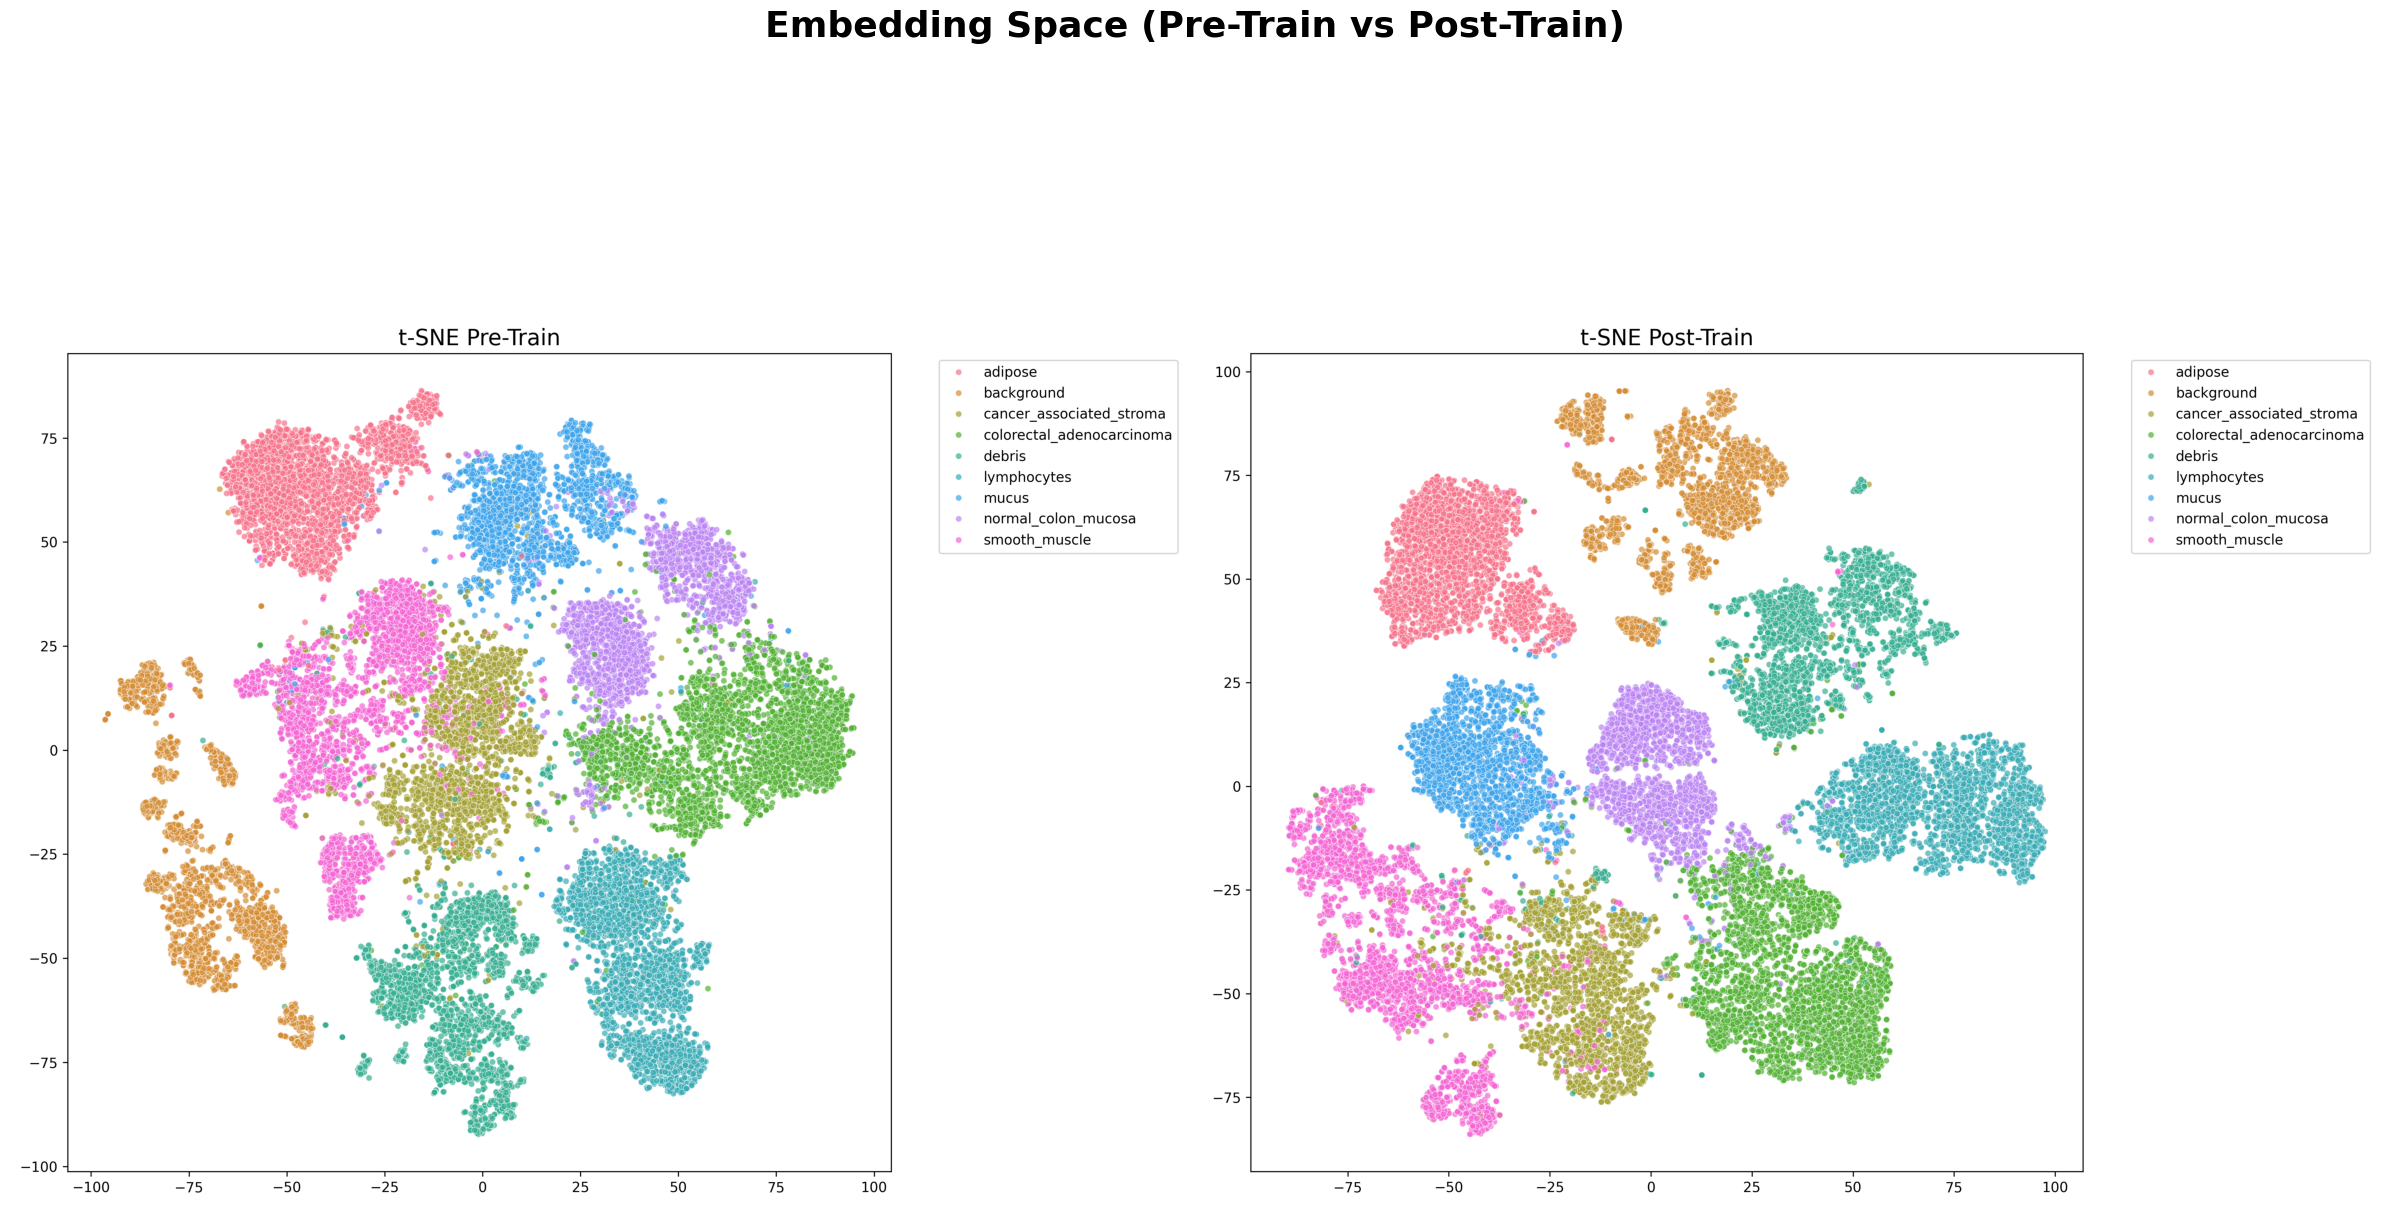

In [23]:
plot_tsne_evolution_grid()